## **Tugas 5: Keyword Extraction**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import re
import nltk
!pip install Sastrawi
nltk.download('punkt')
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.tokenize import sent_tokenize

import networkx as nx
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.0 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [3]:
# Baca file CSV
df = pd.read_csv("/content/drive/MyDrive/PPW/tugas5/hasil_prepros.csv")
df.head()

,judul,tanggal,isi,kategori,cleansing,case_folding,tokenize,stopword_removal
0,"Apriyani Rahayu Sudah Berlatih Lagi, Ingin Com...","Rabu, 06 Nov 2024 15:25 WIB",Jakarta - Atlet bulutangkis Indonesia Apriyani...,Olahraga,Jakarta Atlet bulutangkis Indonesia Apriyani ...,jakarta atlet bulutangkis indonesia apriyani ...,"['jakarta', 'atlet', 'bulutangkis', 'indonesia...",jakarta atlet bulutangkis indonesia apriyani r...
1,Hasil Korea Masters 2024: Putri KW Lanjut ke 1...,"Rabu, 06 Nov 2024 14:36 WIB",Jakarta - Putri Kusuma Wardani hadapi wakil Ta...,Olahraga,Jakarta Putri Kusuma Wardani hadapi wakil Tai...,jakarta putri kusuma wardani hadapi wakil tai...,"['jakarta', 'putri', 'kusuma', 'wardani', 'had...",jakarta putri kusuma wardani hadapi wakil taiw...
2,Fajar/Rian di Japan dan China Masters: Inginny...,"Rabu, 06 Nov 2024 14:13 WIB",Jakarta - Fajar Alfian/Muhammad Rian Ardianto ...,Olahraga,Jakarta Fajar AlfianMuhammad Rian Ardianto be...,jakarta fajar alfianmuhammad rian ardianto be...,"['jakarta', 'fajar', 'alfianmuhammad', 'rian',...",jakarta fajar alfianmuhammad rian ardianto ber...
3,Hasil Korea Masters 2024: Komang Ayu Tersingkir,"Rabu, 06 Nov 2024 12:45 WIB",Jakarta - Komang Ayu Cahya Dewi hadapi Liang T...,Olahraga,Jakarta Komang Ayu Cahya Dewi hadapi Liang Ti...,jakarta komang ayu cahya dewi hadapi liang ti...,"['jakarta', 'komang', 'ayu', 'cahya', 'dewi', ...",jakarta komang ayu cahya dewi hadapi liang tin...
4,Korea Masters 2024 Hari Kedua: Tiga Wakil RI B...,"Rabu, 06 Nov 2024 10:55 WIB",Jakarta - Turnamen Korea Masters 2024 memasuki...,Olahraga,Jakarta Turnamen Korea Masters memasuki hari...,jakarta turnamen korea masters memasuki hari...,"['jakarta', 'turnamen', 'korea', 'masters', 'm...",jakarta turnamen korea masters memasuki penyel...


In [4]:
# mengambil satu sample berita
sample_berita = df['stopword_removal'].iloc[4]

sample_berita_list = [sample_berita]
print(sample_berita)

jakarta turnamen korea masters memasuki penyelenggaraan rabu indonesia menyisakan wakil perjuangannya indonesia menurunkan tujuh wakil turnamen bwf super wakil tiket senin daniel marthinmuhammad shohibul fikri sabar karyaman gutamamoh reza pahlevi isfahani ganda campuran dejan ferdinansyahgloria emanuelle widjaja lolos babak bye ganda putri indonesia jesita putri miantorofebi setianingrum langsung tersingkir kalah hu ling fangjheng yu chieh babak berlanjut memainkan pemain tersisa wakilwakil merah putih tunggal putri komang ayu cahya dewi putri kusuma wardani ganda putri febriana dwipuji kusumaamalia cahya pratiwi menghadapi lawanlawan taiwan laga iksan gymnasium korea selatan lawan komang berjumpa rivalnya kali head to head komang liang imbang jadwalnya lapangan partai komang ayu cahya dewi vs liang ting yu taiwan partai febriana dwipuji kusumaamalia cahya pratiwi vs hsieh pei shanhung entzu taiwan lapangan partai putri kusuma wardani vs huang yu hsun mcyaff


In [5]:
import networkx as nx
from sklearn.feature_extraction.text import TfidfVectorizer

# Inisialisasi TfidfVectorizer tanpa batasan jumlah fitur
vectorizer = TfidfVectorizer()

# Fit dan transform teks ke dalam TF-IDF
tfidf_matrix = vectorizer.fit_transform(sample_berita_list)

# Konversi TF-IDF matrix ke DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())

tfidf_df

,ayu,babak,berjumpa,berlanjut,bwf,bye,cahya,campuran,chieh,daniel,...,to,tujuh,tunggal,turnamen,vs,wakil,wakilwakil,wardani,widjaja,yu
0,0.125,0.125,0.0625,0.0625,0.0625,0.0625,0.25,0.0625,0.0625,0.0625,...,0.0625,0.0625,0.0625,0.125,0.1875,0.1875,0.0625,0.125,0.0625,0.1875


In [6]:
# Ubah nilai TF-IDF di bawah 0.5 menjadi 0, dan di atas atau sama dengan 0.5 menjadi 1
df_tfidf_1berita = tfidf_df.apply(lambda col: col.map(lambda x: 1 if x >= 0.03 else 0))

# Menampilkan DataFrame dengan nilai biner
df_tfidf_1berita

,ayu,babak,berjumpa,berlanjut,bwf,bye,cahya,campuran,chieh,daniel,...,to,tujuh,tunggal,turnamen,vs,wakil,wakilwakil,wardani,widjaja,yu
0,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


In [7]:
# Membuat graf berdasarkan co-occurrence fitur
G = nx.Graph()

# Menambahkan node ke graf
for feature in df_tfidf_1berita.columns:
    G.add_node(feature)

# Menambahkan edge berdasarkan co-occurrence
for i in range(len(df_tfidf_1berita)):
    features = df_tfidf_1berita.iloc[i]
    active_features = features[features == 1].index.tolist()

    for j in range(len(active_features)):
        for k in range(j + 1, len(active_features)):
            G.add_edge(active_features[j], active_features[k])

# Hitung degree centrality
degree_centrality = nx.degree_centrality(G)

# Konversi hasil degree centrality ke DataFrame untuk lebih mudah dilihat
df_degree_centrality = pd.DataFrame(degree_centrality.items(), columns=['Node', 'Degree Centrality'])

# Mengurutkan DataFrame dari yang terbesar sampai terkecil
df_degree_centrality_sorted = df_degree_centrality.sort_values(by='Degree Centrality', ascending=False)

# Tampilkan hasil degree centrality yang sudah diurutkan
print(df_degree_centrality_sorted)

         Node  Degree Centrality
0         ayu                1.0
59    pahlevi                1.0
68       rabu                1.0
67      putri                1.0
66      putih                1.0
..        ...                ...
29  indonesia                1.0
28     imbang                1.0
27      iksan                1.0
26      huang                1.0
92         yu                1.0

[93 rows x 2 columns]


In [8]:
# Ambil top 10 fitur dengan degree centrality tertinggi
top_10_features = df_degree_centrality_sorted.head(10)['Node'].tolist()

# DataFrame yang difilter berdasarkan top 10 fitur
filtered_df_train_tfidf = df_tfidf_1berita.copy()  # Tetap menyimpan semua fitur

# Tampilkan pesan tentang top 10 fitur yang terpilih
print("\nTop 10 fitur berdasarkan degree centrality:")
print(top_10_features)

# Tampilkan DataFrame asli yang masih memiliki semua fitur
print("\nDataFrame asli dengan semua fitur (tanpa menghapus):")
print(filtered_df_train_tfidf)


Top 10 fitur berdasarkan degree centrality:
['ayu', 'pahlevi', 'rabu', 'putri', 'putih', 'pratiwi', 'perjuangannya', 'penyelenggaraan', 'pemain', 'pei']

DataFrame asli dengan semua fitur (tanpa menghapus):
   ayu  babak  berjumpa  berlanjut  bwf  bye  cahya  campuran  chieh  daniel  \
0    1      1         1          1    1    1      1         1      1       1   

   ...  to  tujuh  tunggal  turnamen  vs  wakil  wakilwakil  wardani  widjaja  \
0  ...   1      1        1         1   1      1           1        1        1   

   yu  
0   1  

[1 rows x 93 columns]


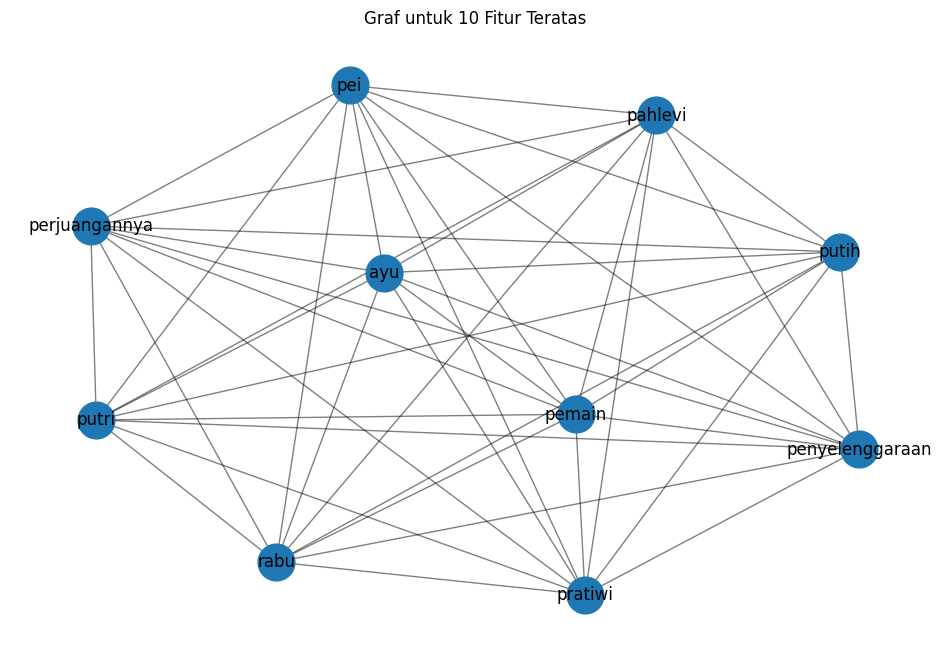

In [9]:
import matplotlib.pyplot as plt
import networkx as nx

# Membuat graf baru hanya untuk fitur teratas
G_top_10 = nx.Graph()

# Menambahkan node teratas ke graf
for feature in top_10_features:
    G_top_10.add_node(feature)

# Pastikan df_tfidf_1berita adalah nama yang benar dari dataframe yang mengandung data biner (TF-IDF)
if 'df_tfidf_1berita' in locals():  # Memeriksa apakah dataframe df_tfidf_1berita sudah ada
    # Menambahkan edge berdasarkan co-occurrence dari fitur teratas
    for i in range(len(df_tfidf_1berita)):  # Pastikan dataframe ini ada dan ukurannya benar
        features = df_tfidf_1berita.iloc[i]
        active_features = features[features == 1].index.tolist()
        active_top_10_features = [f for f in active_features if f in top_10_features]

        for j in range(len(active_top_10_features)):
            for k in range(j + 1, len(active_top_10_features)):
                G_top_10.add_edge(active_top_10_features[j], active_top_10_features[k])

    # Mengatur ukuran figure untuk visualisasi graf
    plt.figure(figsize=(12, 8))

    # Menggambar graf fitur teratas
    pos = nx.spring_layout(G_top_10)  # Menggunakan layout spring
    nx.draw_networkx_nodes(G_top_10, pos, node_size=700)  # Menggambar node
    nx.draw_networkx_edges(G_top_10, pos, width=1.0, alpha=0.5)  # Menggambar edge
    nx.draw_networkx_labels(G_top_10, pos, font_size=12, font_family='sans-serif')  # Menggambar label

    # Menampilkan graf
    plt.title('Graf untuk 10 Fitur Teratas')
    plt.axis('off')  # Menyembunyikan sumbu
    plt.show()
else:
    print("DataFrame 'df_tfidf_1berita' tidak ditemukan. Pastikan proses TF-IDF sudah dilakukan.")


In [10]:
# Menghitung closeness centrality
closeness_centrality = nx.closeness_centrality(G_top_10)

# Menghitung betweenness centrality
betweenness_centrality = nx.betweenness_centrality(G_top_10)

# Konversi hasil centrality ke DataFrame untuk lebih mudah dilihat
df_closeness_centrality = pd.DataFrame(closeness_centrality.items(), columns=['Node', 'Closeness Centrality'])
df_betweenness_centrality = pd.DataFrame(betweenness_centrality.items(), columns=['Node', 'Betweenness Centrality'])

# Menggabungkan semua centrality ke dalam satu DataFrame
df_centrality = pd.merge(df_degree_centrality_sorted, df_closeness_centrality, on='Node')
df_centrality = pd.merge(df_centrality, df_betweenness_centrality, on='Node')

# Menampilkan hasil centrality
print(df_centrality)

              Node  Degree Centrality  Closeness Centrality  \
0              ayu                1.0                   1.0   
1          pahlevi                1.0                   1.0   
2             rabu                1.0                   1.0   
3            putri                1.0                   1.0   
4            putih                1.0                   1.0   
5          pratiwi                1.0                   1.0   
6    perjuangannya                1.0                   1.0   
7  penyelenggaraan                1.0                   1.0   
8           pemain                1.0                   1.0   
9              pei                1.0                   1.0   

   Betweenness Centrality  
0                     0.0  
1                     0.0  
2                     0.0  
3                     0.0  
4                     0.0  
5                     0.0  
6                     0.0  
7                     0.0  
8                     0.0  
9                     0.0 

In [11]:
# Mengambil kata kunci dengan nilai TF-IDF tertinggi untuk setiap dokumen
kata_kunci = df_tfidf_1berita.idxmax(axis=1)
print("\nKata kunci dari setiap dokumen:")
for i, kata in enumerate(kata_kunci):
    print(f"Dokumen {i+1}: {kata}")


Kata kunci dari setiap dokumen:
Dokumen 1: ayu
